In [76]:
import numpy as np
import matplotlib.pyplot as plt
from abc import ABC, abstractmethod

In [77]:
rand_seed = 42 

In [78]:
inputs = np.array([1.2, 5.1, 2.1])
weights = np.array([3.1, 2.1, 8.7])
bias = 3

output = np.dot(inputs, weights) + bias
print(output)

35.7


In [79]:
# 3 neurons with 4 inputs
np.random.seed(rand_seed)

inputs = np.random.uniform(0, 5, size = 4)
weights = [np.random.uniform(0, 2, size = 4) for i in range(3)]
biases = [np.random.uniform(0, 1) for i in range(3)]

output = [np.dot(inputs, weights[i]) + biases[i] for i in range(3)]

print([f"{x:.2f}" for x in output])


['7.98', '15.47', '8.00']


In [80]:
# Improved setup
np.random.seed(rand_seed)

inputs = np.random.uniform(0, 5, size = 4)
weights = np.random.uniform(0, 2, size = (3, 4))
biases = np.random.uniform(0, 1, size = 3)

output = weights @ inputs + biases 

print([f"{x:.2f}" for x in output])


['7.98', '15.47', '8.00']


In [81]:
# Parameterise neurons and inputs

def foo(neuron_size, input_size):
    np.random.seed(rand_seed)

    inputs = np.random.uniform(0, 5, input_size)
    weights = np.random.uniform(0, 2, (neuron_size, input_size))
    biases = np.random.uniform(0, 1, neuron_size)

    print(f"The inputs are {inputs}")
    print(f"\nThe weights are: \n{weights}")
    print(f"\nThe biases are {biases}")

    output = weights @ inputs + biases 
    return output

print(foo(3, 4))

The inputs are [1.87270059 4.75357153 3.65996971 2.99329242]

The weights are: 
[[0.31203728 0.31198904 0.11616722 1.73235229]
 [1.20223002 1.41614516 0.04116899 1.9398197 ]
 [1.66488528 0.42467822 0.36364993 0.36680902]]

The biases are [0.30424224 0.52475643 0.43194502]
[ 7.98226237 15.46504548  7.99742938]


### Some theory

Currently our input has one example i.e 1 vector. For the most part, our model should train on at least an order of magnitude more examples than parameters (the weights and biases). So, combining these examples, will form a matrix of size (# of Examples) x (# of Inputs).

Note:
- Increasing # of examples does not change the weights matrix, since the # of neurons does not need to change.
- We keep inputs as (examples, input_size) — one row per example — and shape weights as (input_size, neuron_size), so `inputs @ weights` lines up directly without needing to transpose anything

We have 15 trainable parameters so good practice would be to use ~ 100 examples but for simplicity lets keep 3

In [82]:
# Increasing the # of examples

def layer(neuron_size, input_size, example_size):
    np.random.seed(rand_seed)

    inputs = np.random.uniform(0, 5, (example_size, input_size))
    weights = np.random.uniform(0, 2, (input_size, neuron_size))
    biases = np.random.uniform(0, 1, (1, neuron_size))

    print(f"The inputs are \n{inputs}")
    print(f"\nThe weights are \n{weights}")
    print(f"\nThe biases are {biases}")

    raw_output = inputs @ weights + biases

    return raw_output

print(layer(neuron_size=3, input_size=4, example_size=3))

The inputs are 
[[1.87270059 4.75357153 3.65996971 2.99329242]
 [0.7800932  0.7799726  0.29041806 4.33088073]
 [3.00557506 3.54036289 0.10292247 4.84954926]]

The weights are 
[[1.66488528 0.42467822 0.36364993]
 [0.36680902 0.60848449 1.04951286]
 [0.86389004 0.58245828 1.22370579]
 [0.27898772 0.5842893  0.73272369]]

The biases are [[0.45606998 0.78517596 0.19967378]]
[[ 9.31445775  8.35367404 12.54159808]
 [ 3.50008848  4.29070944  4.83067106]
 [ 8.2005231   7.1093219   8.68763378]]


In [83]:
# Adding an additional layer so the new input is the previous output

def layer(inputs, neuron_size, input_size):
    weights = np.random.uniform(0, 2, (input_size, neuron_size))
    biases = np.random.uniform(0, 1, (1, neuron_size))

    raw_output = inputs @ weights + biases

    return raw_output

np.random.seed(rand_seed)

example_size = 3
input_size = 4
layer1_neurons = 3
layer2_neurons = 2

initial_inputs = np.random.uniform(0, 5, (example_size, input_size))  # rows = examples

layer1_outputs = layer(initial_inputs, neuron_size=layer1_neurons, input_size=input_size)
layer2_outputs = layer(layer1_outputs, neuron_size=layer2_neurons, input_size=layer1_neurons)

print(f"Layer 1 outputs (shape {layer1_outputs.shape}):\n{layer1_outputs}")
print(f"\nLayer 2 outputs (shape {layer2_outputs.shape}):\n{layer2_outputs}")

Layer 1 outputs (shape (3, 3)):
[[ 9.31445775  8.35367404 12.54159808]
 [ 3.50008848  4.29070944  4.83067106]
 [ 8.2005231   7.1093219   8.68763378]]

Layer 2 outputs (shape (3, 2)):
[[15.5818687  23.78383816]
 [ 6.59471995 10.95472141]
 [13.00623247 20.45060342]]


In [84]:
# Lets make our code more Pythonic

example_size = 3
input_size = 4
layer1_neurons = 5
layer2_neurons = 2

X = np.round(np.random.uniform(low=0, high=5, size=(example_size, input_size)), 2)

print(f"Our input layer is \n{X}")

class LayerDense:
    def __init__(self, n_inputs, n_neurons) -> None:
        self.weights = 0.1 * np.random.randn(n_inputs, n_neurons) # Pre transposed
        self.biases = np.zeros((1, n_neurons))

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)
        self.dinputs = np.dot(dvalues, self.weights.T)

layer1 = LayerDense(input_size, layer1_neurons)
layer2 = LayerDense(layer1_neurons, layer2_neurons)

layer1.forward(X)
layer2.forward(layer1.output)
print(layer2.output)

Our input layer is 
[[4.04 1.52 0.49 3.42]
 [2.2  0.61 2.48 0.17]
 [4.55 1.29 3.31 1.56]]
[[ 0.05048711 -0.10514344]
 [ 0.01289204 -0.04135009]
 [ 0.0335581  -0.09862696]]


In [85]:
# Activation functions (ReLU)

inputs = np.array([0, 2, -1, 3.3, -2.7, 1.1, 2.2, -100])
output = [max(0, input) for input in inputs]

print(output)


[0, np.float64(2.0), 0, np.float64(3.3), 0, np.float64(1.1), np.float64(2.2), 0]


In [86]:
class ActivationReLU:
    def __init__(self) -> None:
        pass

    def forward(self, inputs):
        self.inputs = inputs
        self.output = np.maximum(0, inputs)

    def backward(self, dvalues):
        self.dinputs = dvalues.copy()
        self.dinputs[self.inputs <= 0] = 0

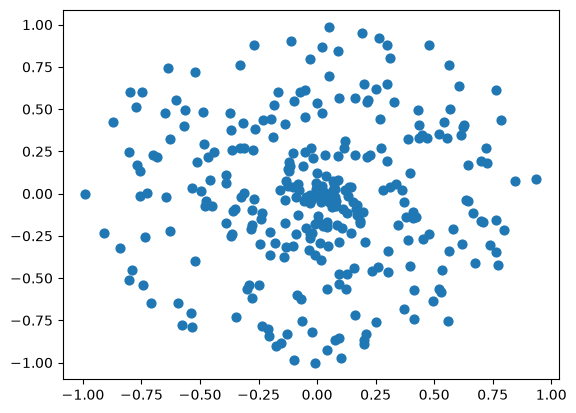

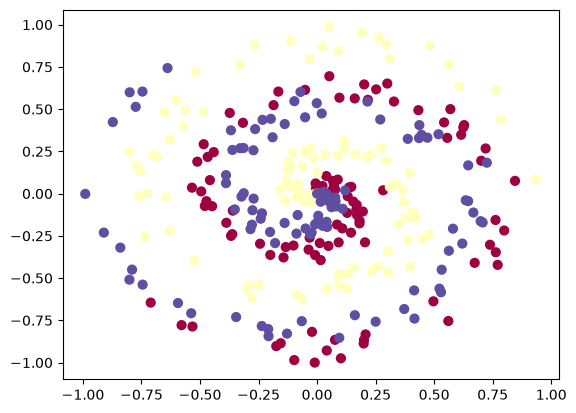

In [87]:
# Creating some data
def spiral_data(points, classes):
    X = np.zeros((points*classes, 2))
    y = np.zeros(points*classes, dtype='uint8')
    for class_number in range(classes):
        ix = range(points*class_number, points*(class_number+1))
        r = np.linspace(0.0, 1, points)  # radius
        t = np.linspace(class_number*4, (class_number+1)*4, points) + np.random.randn(points)*0.2
        X[ix] = np.c_[r*np.sin(t*2.5), r*np.cos(t*2.5)]
        y[ix] = class_number
    return X, y

X, y = spiral_data(100, 3)

# uncolored, for comparison:
plt.scatter(X[:, 0], X[:, 1], s=40)
plt.show()

# lets visualize the data, colored by class:
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.show()

In [88]:
layer1 = LayerDense(2, 5)
activation1 = ActivationReLU()

layer1.forward(X)
print(layer1.output) # Notice the -ve values
activation1.forward(layer1.output)
print(activation1.output) # Notice the non -ve values

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-2.15370193e-03 -1.65067092e-03  3.10352800e-04  1.90974393e-04
   1.22309471e-03]
 [-1.64727909e-03  2.71061056e-03 -5.31243208e-04 -2.96098119e-03
   1.37001796e-03]
 ...
 [-4.17335079e-02 -1.92200005e-01  3.70078968e-02  1.28990114e-01
   6.17880155e-03]
 [ 1.44105056e-01 -7.73044850e-02  1.55554229e-02  1.34046030e-01
  -1.02371196e-01]
 [ 7.73067460e-03 -1.77432359e-01  3.43571870e-02  1.42702441e-01
  -2.44431543e-02]]
[[0.         0.         0.         0.         0.        ]
 [0.         0.         0.00031035 0.00019097 0.00122309]
 [0.         0.00271061 0.         0.         0.00137002]
 ...
 [0.         0.         0.0370079  0.12899011 0.0061788 ]
 [0.14410506 0.         0.01555542 0.13404603 0.        ]
 [0.00773067 0.         0.03435719 0.14270244 0.        ]]


In [89]:
# Developing a softmax activation intuition.

layer_outputs = [[4.8, 1.21, 2.385],
                 [8.9, 3.21, 2.85],
                 [5.8, -1.01, 2.385]]

exp_values = np.exp(layer_outputs)
norm_values = exp_values / np.sum(exp_values, axis=1, keepdims=True)
print(norm_values)

# One thing to note is that we're going to subtract the largest value from each vector to prevent an overflow error. 
# Interestingly, makes no difference to the final output


[[0.89528266 0.02470831 0.08000903]
 [0.99429528 0.00336031 0.00234441]
 [0.96713754 0.00106646 0.03179601]]


In [90]:
class ActivationSoftmax:
    def __init__(self) -> None:
        ...

    def forward(self, inputs):
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True))
        probs = exp_values / np.sum(exp_values, axis=1, keepdims=True)

        self.output = probs

    def backward(self, dvalues):
        self.dinputs = np.empty_like(dvalues)
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)):
            single_output = single_output.reshape(-1, 1)
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T)
            self.dinputs[index] = np.dot(jacobian_matrix, single_dvalues)

X, y = spiral_data(points=100, classes=3)

dense1 = LayerDense(2, 3)
activation1 = ActivationReLU()

dense2 = LayerDense(3, 3)
activation2 = ActivationSoftmax()

dense1.forward(X)
activation1.forward(dense1.output)
dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])

[[0.33333333 0.33333333 0.33333333]
 [0.33333333 0.33333333 0.33333333]
 [0.33333099 0.33333448 0.33333453]
 [0.33330817 0.33334563 0.3333462 ]
 [0.33331147 0.33334401 0.33334451]]


In [91]:
# Breaking down the loss function: Categorical Cross-Entropy

softmax_output = np.array([0.7, 0.1, 0.2])
target_output = np.array([1, 0, 0])

loss = -(np.log(softmax_output[0]) * target_output[0] +
         np.log(softmax_output[1]) * target_output[1] +
         np.log(softmax_output[2]) * target_output[2])

print(loss)

# Equivalent loss
loss = -np.log(softmax_output[0])
print(loss)

0.35667494393873245
0.35667494393873245


In [92]:
class Loss(ABC):
    def __init__(self) -> None:
        ...

    @abstractmethod
    def forward(self, output, y):
        pass
    
    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss

    

class LossCategoricalCrossentropy(Loss):
    def __init__(self) -> None:
        super().__init__()

    def forward(self, y_pred, y_true):
        samples = len(y_pred)
        y_pred_clipped = np.clip(y_pred, 1e-7, 1-1e-7)

        if len(y_true.shape) == 1:
            correct_confidences = y_pred_clipped[range(samples), y_true]

        elif len(y_true.shape) == 2:
            correct_confidences = np.sum(y_pred_clipped*y_true, axis=1)

        negative_log_likelihoods = -np.log(correct_confidences)
        return negative_log_likelihoods

    def backward(self, dvalues, y_true):
        samples = len(dvalues)
        labels = len(dvalues[0])

        if len(y_true.shape) == 1:
            y_true = np.eye(labels)[y_true]

        self.dinputs = -y_true / dvalues
        self.dinputs = self.dinputs / samples


X, y = spiral_data(points=100, classes=3)

dense1 = LayerDense(2,3)
activation1 = ActivationReLU()

dense2 = LayerDense(3, 3)
activation2 = ActivationSoftmax()

dense1.forward(X)
activation1.forward(dense1.output)

dense2.forward(activation1.output)
activation2.forward(dense2.output)

print(activation2.output[:5])

loss_function = LossCategoricalCrossentropy()
loss = loss_function.calculate(activation2.output, y)

print("Loss:", loss)

[[0.33333333 0.33333333 0.33333333]
 [0.33334367 0.33331654 0.3333398 ]
 [0.33324682 0.33343494 0.33331824]
 [0.3333509  0.33330201 0.33334708]
 [0.33328917 0.33337467 0.33333615]]
Loss: 1.0983269350058764


In [93]:
# Backpropagation: walk the gradient back through the network, layer by layer

loss_function.backward(activation2.output, y)
activation2.backward(loss_function.dinputs)
dense2.backward(activation2.dinputs)
activation1.backward(dense2.dinputs)
dense1.backward(activation1.dinputs)

print("dense1.dweights:\n", dense1.dweights)
print("\ndense1.dbiases:\n", dense1.dbiases)
print("\ndense2.dweights:\n", dense2.dweights)
print("\ndense2.dbiases:\n", dense2.dbiases)

dense1.dweights:
 [[ 8.17955724e-05  8.34663569e-04 -3.24462521e-03]
 [ 2.35954578e-03 -2.83598720e-03  3.58354514e-03]]

dense1.dbiases:
 [[ 0.00309242  0.00265199 -0.01023628]]

dense2.dweights:
 [[ 0.00109671 -0.00085005 -0.00024666]
 [-0.00054694 -0.0008166   0.00136354]
 [-0.00130093  0.00115784  0.0001431 ]]

dense2.dbiases:
 [[ 6.28165758e-05  1.31371632e-04 -1.94188208e-04]]


In [94]:
# Combining Softmax activation and Categorical Cross-Entropy loss for a faster backward step

class ActivationSoftmaxLossCategoricalCrossentropy:
    def __init__(self) -> None:
        self.activation = ActivationSoftmax()
        self.loss = LossCategoricalCrossentropy()

    def forward(self, inputs, y_true):
        self.activation.forward(inputs)
        self.output = self.activation.output
        return self.loss.calculate(self.output, y_true)

    def backward(self, dvalues, y_true):
        samples = len(dvalues)

        if len(y_true.shape) == 2:
            y_true = np.argmax(y_true, axis=1)

        self.dinputs = dvalues.copy()
        self.dinputs[range(samples), y_true] -= 1
        self.dinputs = self.dinputs / samples

In [95]:
# Verify the combined backward pass agrees with the separate softmax + loss backward pass above,
# reusing the same dense2.output rather than a freshly re-initialized network

loss_activation = ActivationSoftmaxLossCategoricalCrossentropy()
combined_loss = loss_activation.forward(dense2.output, y)

print(loss_activation.output[:5])
print("Loss:", combined_loss)

loss_activation.backward(loss_activation.output, y)

print("\nCombined dinputs match separate softmax+loss dinputs:",
      np.allclose(loss_activation.dinputs, activation2.dinputs))

[[0.33333333 0.33333333 0.33333333]
 [0.33334367 0.33331654 0.3333398 ]
 [0.33324682 0.33343494 0.33331824]
 [0.3333509  0.33330201 0.33334708]
 [0.33328917 0.33337467 0.33333615]]
Loss: 1.0983269350058764

Combined dinputs match separate softmax+loss dinputs: True


In [ ]:
# Optimizer: nudge each layer's weights and biases against their gradients

class OptimizerSGD:
    def __init__(self, learning_rate=1.0) -> None:
        self.learning_rate = learning_rate

    def update_params(self, layer):
        layer.weights += -self.learning_rate * layer.dweights
        layer.biases += -self.learning_rate * layer.dbiases

In [ ]:
# Training loop: forward, measure loss/accuracy, backward, step the optimizer

X, y = spiral_data(points=100, classes=3)

dense1 = LayerDense(2, 64)
activation1 = ActivationReLU()

dense2 = LayerDense(64, 3)
loss_activation = ActivationSoftmaxLossCategoricalCrossentropy()

optimizer = OptimizerSGD()

for epoch in range(10001):
    dense1.forward(X)
    activation1.forward(dense1.output)
    dense2.forward(activation1.output)
    loss = loss_activation.forward(dense2.output, y)

    predictions = np.argmax(loss_activation.output, axis=1)
    accuracy = np.mean(predictions == y)

    if epoch % 1000 == 0:
        print(f"epoch: {epoch}, acc: {accuracy:.3f}, loss: {loss:.3f}")

    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    optimizer.update_params(dense1)
    optimizer.update_params(dense2)